<a href="https://colab.research.google.com/github/Ashish-kharde1/credit-card-fraud-detection/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
!pip install lightgbm imbalanced-learn shap

## Import Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import precision_score, recall_score, fbeta_score, roc_auc_score, matthews_corrcoef, classification_report
import pickle

## Data Profiling

In [56]:
# Load the fraud dataset from the CSV file into a Pandas DataFrame
df = pd.read_csv('fraud.csv')

# Display the first five rows of the dataset to get an initial view of the data
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:01:18,370894326983440,fraud_Huels-Hahn,gas_transport,6.30,David,Cantrell,M,580 Johnson Stream Suite 505,...,46.0614,-118.3315,41056,Ambulance person,1970-07-23,d5afdda08da79247e865d6a25c5376a1,1546300878,46.239774,-118.475879,0
1,1,2019-01-01 00:02:06,38589178390843,"fraud_Kutch, Hermiston and Farrell",gas_transport,193.54,Judith,Maynard,F,6617 Jones Common,...,29.8272,-95.4266,2906700,IT technical support officer,1981-11-24,b3778d10e1313f8f65dcdd68eba0bdc9,1546300926,30.632886,-95.169417,0
2,2,2019-01-01 00:02:10,2597269999498120,fraud_Bernhard Inc,gas_transport,77.59,Kayla,Gonzalez,F,36660 Jasmin Circle,...,42.3320,-83.4695,90173,"Accountant, chartered public finance",1965-05-04,5247e40d36c8653595cb70428a04b5fb,1546300930,42.882717,-84.336792,0
3,3,2019-01-01 00:03:24,3594406409097438,fraud_Torp-Labadie,gas_transport,99.00,Lawrence,Gomez,M,421 Kyle Mill,...,34.6313,-92.4727,14134,Analytical chemist,1984-06-10,63bc7f8d8402de4d2c6bebf3c5db7923,1546301004,34.329257,-93.200352,0
4,4,2019-01-01 00:04:26,347208496498560,fraud_Friesen-D'Amore,gas_transport,47.89,Allen,White,M,2531 Diane Landing Apt. 510,...,27.8116,-82.8014,341043,"Investment banker, operational",2004-08-10,c9caccc7d2b6d315aa5f19ec34cf35c0,1546301066,26.848567,-82.336277,0


In [57]:
# Display a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222460 entries, 0 to 1222459
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1222460 non-null  int64  
 1   trans_date_trans_time  1222460 non-null  object 
 2   cc_num                 1222460 non-null  int64  
 3   merchant               1222460 non-null  object 
 4   category               1222460 non-null  object 
 5   amt                    1222460 non-null  float64
 6   first                  1222460 non-null  object 
 7   last                   1222460 non-null  object 
 8   gender                 1222460 non-null  object 
 9   street                 1222460 non-null  object 
 10  city                   1222460 non-null  object 
 11  state                  1222460 non-null  object 
 12  zip                    1222460 non-null  int64  
 13  lat                    1222460 non-null  float64
 14  long              

In [58]:
# Generates descriptive statistics for the numerical columns in the DataFrame
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.222460e+06,1.222460e+06,1.222460e+06,1.222460e+06,1.222460e+06,1.222460e+06,1.222460e+06,1.222460e+06,1.222460e+06,1.222460e+06,1.222460e+06
mean,6.112295e+05,3.265111e+17,7.400999e+01,5.025187e+04,3.784372e+01,-9.164769e+01,3.118306e+05,1.570123e+09,3.784362e+01,-9.164783e+01,5.838228e-03
std,3.528939e+05,1.167619e+18,1.545540e+02,3.026236e+04,5.586639e+00,1.686744e+01,5.888311e+05,1.285153e+07,5.616135e+00,1.687720e+01,7.618496e-02
min,0.000000e+00,6.040616e+10,1.000000e+00,1.040000e+03,1.948010e+01,-1.580103e+02,8.200000e+01,1.546301e+09,1.869077e+01,-1.590079e+02,0.000000e+00
25%,3.056148e+05,1.800180e+14,9.540000e+00,2.366200e+04,3.391570e+01,-9.831740e+01,1.394500e+04,1.559626e+09,3.389467e+01,-9.841674e+01,0.000000e+00
50%,6.112295e+05,3.516698e+15,4.983000e+01,4.812700e+04,3.885900e+01,-8.706560e+01,5.749200e+04,1.570138e+09,3.883072e+01,-8.705239e+01,0.000000e+00
75%,9.168442e+05,4.503687e+15,8.455000e+01,7.820100e+04,4.153430e+01,-7.951340e+01,2.701000e+05,1.580339e+09,4.156280e+01,-7.932880e+01,0.000000e+00
max,1.222459e+06,4.997335e+18,2.994773e+04,9.980100e+04,7.123460e+01,-6.786880e+01,2.906700e+06,1.592698e+09,7.223426e+01,-6.687092e+01,1.000000e+00


In [59]:
# Count the number of transactions for each value in the 'is_fraud' column
# 0 represents legitimate transactions, while 1 represents fraudulent transactions
counts = df.is_fraud.value_counts()

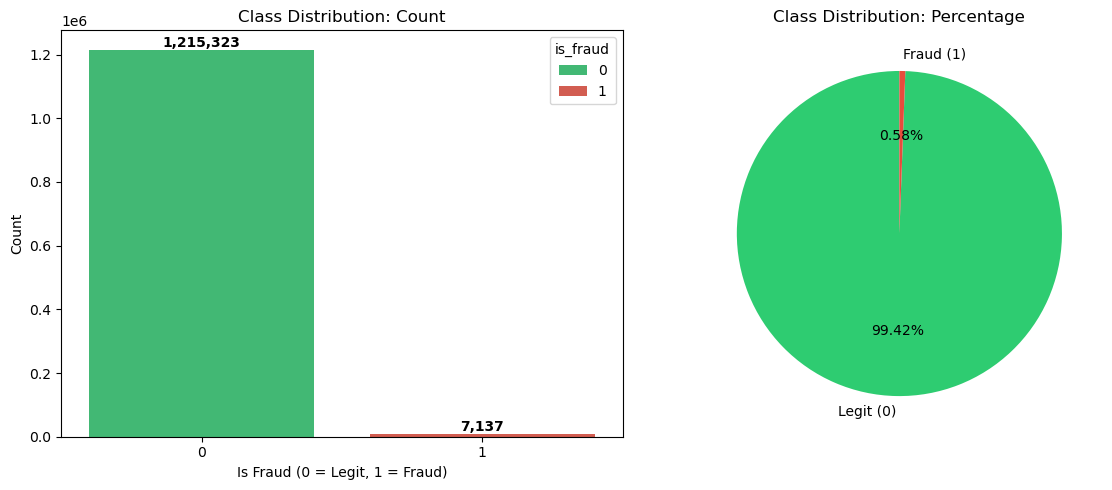

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart with counts
sns.countplot(x='is_fraud', data=df, ax=axes[0], hue='is_fraud', palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution: Count')
axes[0].set_xlabel('Is Fraud (0 = Legit, 1 = Fraud)')
axes[0].set_ylabel('Count')

# Annotate bars with actual numbers
for i, v in enumerate(counts):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart with percentages (great for showing imbalance)
axes[1].pie(counts, labels=['Legit (0)', 'Fraud (1)'], autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Class Distribution: Percentage')

plt.tight_layout()
plt.show()

In [61]:
# Remove columns that are not required for the analysis or machine learning model.
df.drop(["cc_num","merchant","first","last","street","zip","trans_num","Unnamed: 0"], axis=1, inplace=True)

In [62]:
df.columns

Index(['trans_date_trans_time', 'category', 'amt', 'gender', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

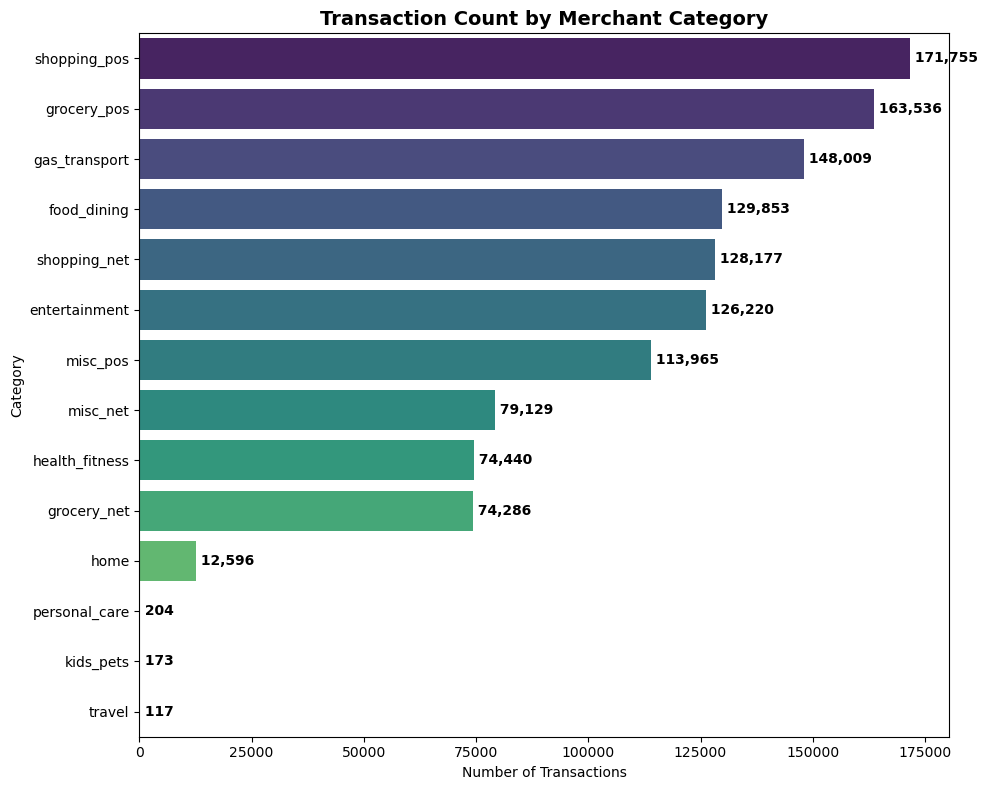

In [63]:
# Count the number of occurrences of each unique value in the 'category' column
category_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    hue=category_counts.index,
    palette='viridis',
    legend=False,
    ax=ax
)

ax.set_title('Transaction Count by Merchant Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Category')

# Annotate bars with counts
for i, v in enumerate(category_counts.values):
    ax.text(v, i, f' {v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Engineering

In [64]:
# Convert the 'dob' (date of birth) column from a string/object format
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

# Calculate each customer's age by subtracting their date of birth
df['age'] = (pd.Timestamp.now() - df['dob']).dt.days // 365

# Remove the original 'dob' column from the DataFrame since the
df.drop('dob', axis=1, inplace=True)

In [65]:
# computing the distance between a cardholder's location and the merchant's location

def haversine(lat1, lon1, lat2, lon2):
  R = 6371 #Earth radius in Km
  lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
  return 2 * R * np.arcsin(np.sqrt(a))

df['distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

In [66]:
# Convert the 'trans_date_trans_time' column from a string/object
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['weekday'] = df['trans_date_trans_time'].dt.weekday

df.drop('trans_date_trans_time', axis=1, inplace=True)

## Label Encoding

In [67]:
# Convery all categorical columns from text labels to numerical values
cat_cols = ['category','gender','city','state','job']

encoder = LabelEncoder()

df["category"] = encoder.fit_transform(df["category"])
df["gender"] = encoder.fit_transform(df["gender"])
df["city"] = encoder.fit_transform(df["city"])
df["state"] = encoder.fit_transform(df["state"])
df["job"] = encoder.fit_transform(df["job"])

In [68]:
df.columns

Index(['category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop',
       'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'age',
       'distance', 'hour', 'day', 'month', 'weekday'],
      dtype='object')

In [69]:
df.head()

,category,amt,gender,city,state,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age,distance,hour,day,month,weekday
0,2,6.30,1,671,47,46.0614,-118.3315,41056,26,1546300878,46.239774,-118.475879,0,56,22.739676,0,1,1,1
1,2,193.54,0,279,43,29.8272,-95.4266,2906700,224,1546300926,30.632886,-95.169417,0,44,92.932957,0,1,1,1
2,2,77.59,0,88,22,42.3320,-83.4695,90173,5,1546300930,42.882717,-84.336792,0,61,93.743788,0,1,1,1
3,2,99.00,1,5,2,34.6313,-92.4727,14134,28,1546301004,34.329257,-93.200352,0,42,74.675413,0,1,1,1
4,2,47.89,1,559,9,27.8116,-82.8014,341043,240,1546301066,26.848567,-82.336277,0,22,116.524796,0,1,1,1


## ML Pipeline

In [70]:
# target fetaure
target = 'is_fraud'

# numerical fetaures
num_features = [
    'amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'age', 'distance',
    'hour', 'day', 'month', 'weekday'
]

# categorical fetaures
cat_features = [
    'category', 'gender', 'state', 'city', 'job'
]

In [71]:
# Pipeline for preprocessing numerical features
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline for preprocessing categorical features
cat_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine the numerical and categorical preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])

## Data Splitting

In [72]:
X = df.drop(target, axis=1)
y = df[target]
X_preprocessed = preprocessor.fit_transform(X)

In [73]:
X_preprocessed[:5].toarray()

array([[-0.43809934,  1.47095228, -1.58197255, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.77338696, -1.43494619, -0.2240361 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.02316352,  0.80339504,  0.48485073, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.1616912 , -0.57501919, -0.04891163, ...,  0.        ,
         0.        ,  0.        ],
       [-0.16900238, -1.7957357 ,  0.5244596 , ...,  0.        ,
         0.        ,  0.        ]])

In [74]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

model = lgb.LGBMClassifier()

In [75]:
# LightGBM Dataset from the training features (X_train)
train_data = lgb.Dataset(X_train, label=y_train)

# LightGBM Dataset from the validation/test features (X_test)
val_data   = lgb.Dataset(X_test, label=y_test, reference=train_data)

In [76]:
params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,  # Decreased learning rate
    "num_leaves": 20,       # Reduced number of leaves
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 0.3, # Increased L1 regularization
    "lambda_l2": 0.3, # Increased L2 regularization
    "metric": ["auc"],
    "verbosity": -1,
    "is_unbalance": True,   # important for fraud detection
    "min_child_samples": 25 # Increased minimum child samples
}

In [77]:
# train model

from lightgbm import early_stopping, log_evaluation

model = lgb.train(
    params,
    train_data,
    num_boost_round=10,  # Increased number of boosting rounds
    valid_sets=[train_data, val_data],
    valid_names=["train","val"],
    callbacks=[early_stopping(100), log_evaluation(100)] # Increased early stopping rounds
)

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[10]	train's auc: 0.977361	val's auc: 0.978157


## Model Evaluation

In [78]:
from sklearn.metrics import precision_score, recall_score, fbeta_score, roc_auc_score, matthews_corrcoef, classification_report

# If you trained with lgb.train()
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)  # gives probability of fraud (class=1)
y_pred = (y_pred_proba > 0.5).astype(int)  # threshold at 0.5



print("AUC:", roc_auc_score(y_test, y_pred_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F2-score:", fbeta_score(y_test, y_pred, beta=2))
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

AUC: 0.9781568099212303
Precision: 0.851409978308026
Recall: 0.5501051156271899
F2-score: 0.5920060331825038
MCC: 0.6829616552451112

Classification Report:
               precision    recall  f1-score   support

           0     0.9974    0.9994    0.9984    243065
           1     0.8514    0.5501    0.6684      1427

    accuracy                         0.9968    244492
   macro avg     0.9244    0.7748    0.8334    244492
weighted avg     0.9965    0.9968    0.9965    244492



In [79]:

# Save the model
with open('lgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)